# Lab Assignment 4 — NLP Preprocessing and Text Classification

**Dataset:** Twitter US Airline Sentiment (Kaggle)  
**Task:** Sentiment Classification — Positive / Neutral / Negative  
**Vectorization:** TF-IDF & CountVectorizer  
**Classifiers:** Multinomial Naive Bayes, Random Forest, Linear SVM  
**Name:** Abhay Bhise (202402040016)

**Course:** Deep Learning (PEC)
---

### Objective
Implement NLP preprocessing techniques and build a text classification model:
1. Apply preprocessing — tokenization, stopword removal, stemming, lemmatization
2. Implement text vectorization — TF-IDF and CountVectorizer
3. Build and compare machine learning classification models
4. Evaluate using accuracy, precision, recall, F1-score, confusion matrix

## Step 1: Install Libraries & Download NLTK Resources

In [2]:
!pip install kagglehub nltk scikit-learn pandas numpy matplotlib seaborn wordcloud -q

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print(' All libraries installed and NLTK resources downloaded!')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


 All libraries installed and NLTK resources downloaded!


In [3]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud

print('All imports successful.')

All imports successful.


## Step 2: Load Dataset

We use the **Twitter US Airline Sentiment** dataset from Kaggle.  
It contains ~14,000 tweets about US airlines labeled as **Positive**, **Neutral**, or **Negative**.

> Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

In [4]:
# Download dataset via kagglehub
path = kagglehub.dataset_download('crowdflower/twitter-airline-sentiment')
print('Dataset path:', path)

import os
print('Files:', os.listdir(path))

# Load CSV
df = pd.read_csv(f'{path}/Tweets.csv')
print(f'\nDataset shape: {df.shape}')
df.head()

100%|██████████| 2.55M/2.55M [00:00<00:00, 49.3MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4
Files: ['database.sqlite', 'Tweets.csv']



Dataset shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
# Keep only relevant columns
df = df[['text', 'airline_sentiment']].copy()
df.columns = ['text', 'sentiment']

# Drop nulls
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Total samples : {len(df)}')
print(f'\nSentiment distribution:')
print(df['sentiment'].value_counts())
print(f'\nSample tweets:')
df.head(3)

Total samples : 14640

Sentiment distribution:
sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sample tweets:


,text,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral


## Step 3: Exploratory Data Analysis (EDA)

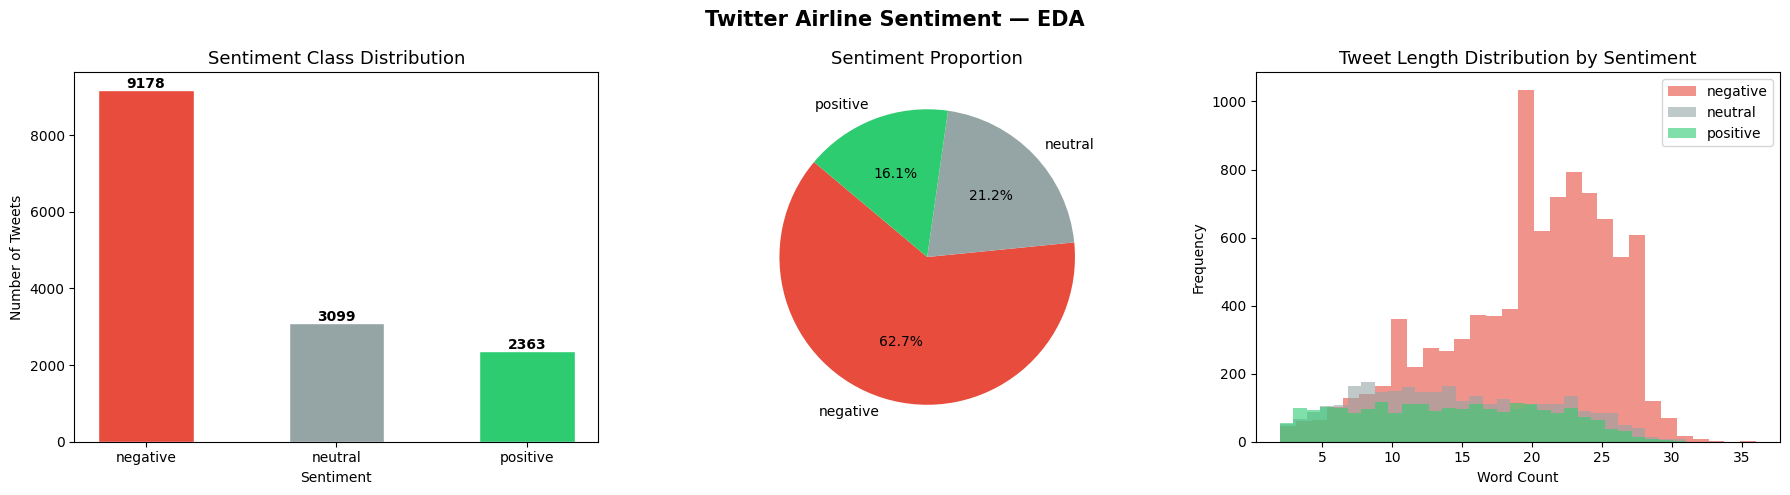

Average tweet length: 17.7 words


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sentiment count bar chart
sentiment_counts = df['sentiment'].value_counts()
colors = ['#E74C3C', '#95A5A6', '#2ECC71']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Sentiment Class Distribution', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Sentiment Proportion', fontsize=13)

# 3. Tweet length distribution by sentiment
df['tweet_length'] = df['text'].apply(lambda x: len(x.split()))
for sentiment, color in zip(['negative', 'neutral', 'positive'], colors):
    subset = df[df['sentiment'] == sentiment]['tweet_length']
    axes[2].hist(subset, bins=30, alpha=0.6, label=sentiment, color=color)
axes[2].set_title('Tweet Length Distribution by Sentiment', fontsize=13)
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Twitter Airline Sentiment — EDA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

print(f'Average tweet length: {df["tweet_length"].mean():.1f} words')

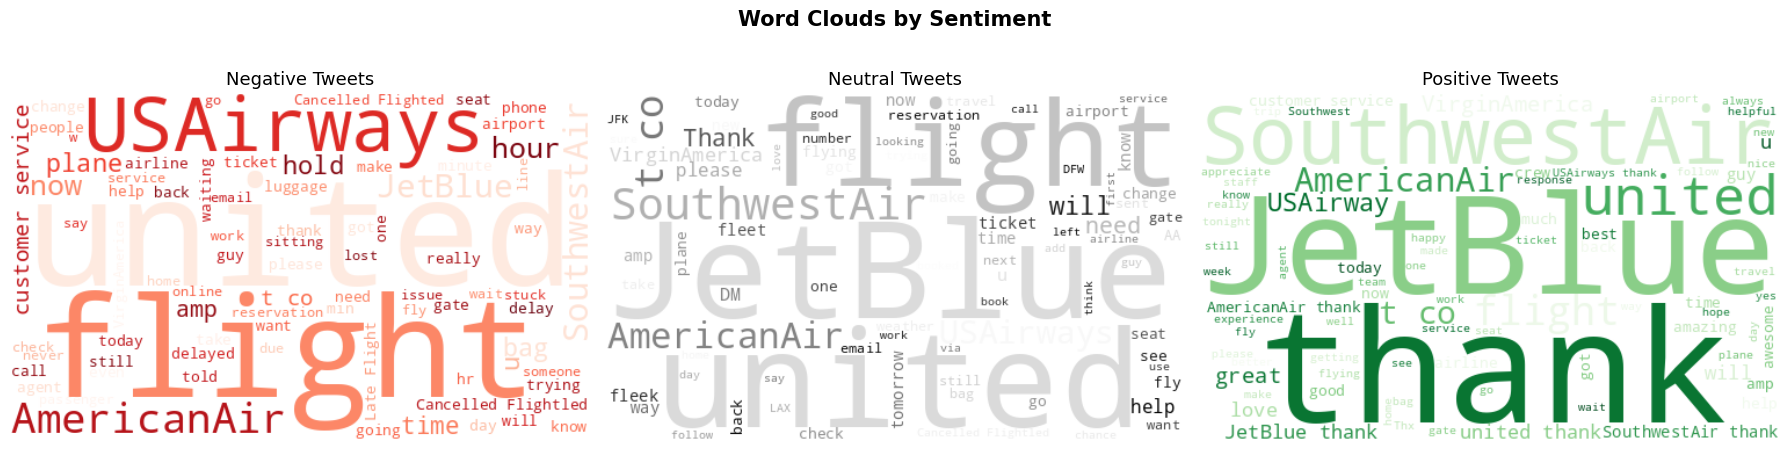

In [7]:
# Word Cloud per sentiment class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
wc_colors = {'negative': 'Reds', 'neutral': 'Greys', 'positive': 'Greens'}

for ax, sentiment in zip(axes, ['negative', 'neutral', 'positive']):
    text = ' '.join(df[df['sentiment'] == sentiment]['text'].tolist())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=wc_colors[sentiment], max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Tweets', fontsize=13)
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

## Step 4: NLP Preprocessing Pipeline

Raw tweets contain noise — URLs, mentions (@user), hashtags, special characters. We apply a comprehensive cleaning + NLP pipeline:

| Step | Technique | Purpose |
|------|-----------|--------|
| 1 | Lowercase | Reduce vocabulary size |
| 2 | Remove URLs, mentions, hashtags | Remove Twitter-specific noise |
| 3 | Remove special characters & digits | Remove non-alphabetic noise |
| 4 | Tokenization | Split text into words |
| 5 | Stopword Removal | Remove common uninformative words |
| 6 | Stemming | Reduce words to root (e.g. running → run) |
| 7 | Lemmatization | Context-aware root extraction (e.g. better → good) |

In [8]:
stop_words  = set(stopwords.words('english'))
stemmer     = PorterStemmer()
lemmatizer  = WordNetLemmatizer()

def preprocess_tweet(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove special characters, digits, punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # 5. Tokenize
    tokens = word_tokenize(text)
    # 6. Remove stopwords and very short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    # 8. Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Apply preprocessing
print('Preprocessing tweets...')
df['clean_text'] = df['text'].apply(preprocess_tweet)
print('Preprocessing complete!')

# Show before/after
print('\n--- Before vs After Preprocessing ---')
for i in range(3):
    print(f'\n[{i+1}] BEFORE: {df["text"].iloc[i]}')
    print(f'    AFTER : {df["clean_text"].iloc[i]}')

Preprocessing tweets...
Preprocessing complete!

--- Before vs After Preprocessing ---

[1] BEFORE: @VirginAmerica What @dhepburn said.
    AFTER : said

[2] BEFORE: @VirginAmerica plus you've added commercials to the experience... tacky.
    AFTER : plu youv ad commerci experi tacki

[3] BEFORE: @VirginAmerica I didn't today... Must mean I need to take another trip!
    AFTER : didnt today must mean need take anoth trip


In [9]:
# Show token count before vs after
df['original_len'] = df['text'].apply(lambda x: len(x.split()))
df['clean_len']    = df['clean_text'].apply(lambda x: len(x.split()))

print(f'Avg tokens BEFORE preprocessing: {df["original_len"].mean():.1f}')
print(f'Avg tokens AFTER  preprocessing: {df["clean_len"].mean():.1f}')
reduction = (1 - df['clean_len'].mean() / df['original_len'].mean()) * 100
print(f'Token reduction: {reduction:.1f}%  ← noise removed successfully')

Avg tokens BEFORE preprocessing: 17.7
Avg tokens AFTER  preprocessing: 8.3
Token reduction: 53.2%  ← noise removed successfully


## Step 5: Text Vectorization

Machine learning models require numerical input. We use two strategies:
- **CountVectorizer** — raw word frequency counts (Bag of Words)
- **TF-IDF Vectorizer** — weights words by importance across documents (preferred)

In [10]:
# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])   # negative=0, neutral=1, positive=2
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f'\nTrain size: {len(X_train)}')
print(f'Test size : {len(X_test)}')

Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Train size: 11712
Test size : 2928


In [11]:
# TF-IDF Vectorizer (unigrams + bigrams)
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# CountVectorizer (unigrams + bigrams)
cv = CountVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
X_train_cv = cv.fit_transform(X_train)
X_test_cv  = cv.transform(X_test)

print(f'TF-IDF feature matrix shape : {X_train_tfidf.shape}')
print(f'CountVec feature matrix shape: {X_train_cv.shape}')

# Top TF-IDF terms per sentiment
print('\nTop 10 TF-IDF features:')
feature_names = tfidf.get_feature_names_out()
# Show top 10 by mean TF-IDF score
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_indices = mean_tfidf.argsort()[-10:][::-1]
for idx in top_indices:
    print(f'  {feature_names[idx]:25s} {mean_tfidf[idx]:.4f}')

TF-IDF feature matrix shape : (11712, 12813)
CountVec feature matrix shape: (11712, 12813)

Top 10 TF-IDF features:
  flight                    0.0332
  thank                     0.0294
  get                       0.0155
  hour                      0.0122
  help                      0.0115
  delay                     0.0112
  cancel                    0.0109
  servic                    0.0108
  time                      0.0106
  custom                    0.0103


## Step 6: Model Training

We train **3 classifiers** on both vectorizers:
- **Multinomial Naive Bayes** — probabilistic baseline, fast
- **Linear SVM** — strong text classifier, handles high dimensions well
- **Random Forest** — ensemble tree-based model, robust to noise

In [13]:
import time

models = {
    'Naive Bayes'   : MultinomialNB(alpha=0.5),
    'Linear SVM'    : LinearSVC(C=1.0, max_iter=3000),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

vectorizers = {
    'TF-IDF'  : (X_train_tfidf, X_test_tfidf),
    'CountVec': (X_train_cv,    X_test_cv)
}

results = {}

for vec_name, (X_tr, X_te) in vectorizers.items():
    for model_name, model in models.items():
        key = f'{model_name} + {vec_name}'
        print(f'Training: {key} ...')
        start = time.time()
        model.fit(X_tr, y_train)
        train_time = time.time() - start
        y_pred = model.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        results[key] = {
            'accuracy'  : acc,
            'y_pred'    : y_pred,
            'train_time': train_time
        }
        print(f'   Accuracy: {acc*100:.2f}%  |  Train time: {train_time:.1f}s\n')

print('All models trained!')

Training: Naive Bayes + TF-IDF ...
   Accuracy: 73.05%  |  Train time: 0.0s

Training: Linear SVM + TF-IDF ...
   Accuracy: 77.73%  |  Train time: 0.3s

Training: Random Forest + TF-IDF ...
   Accuracy: 77.05%  |  Train time: 44.0s

Training: Naive Bayes + CountVec ...
   Accuracy: 76.26%  |  Train time: 0.0s

Training: Linear SVM + CountVec ...
   Accuracy: 76.30%  |  Train time: 0.6s

Training: Random Forest + CountVec ...
   Accuracy: 76.57%  |  Train time: 27.4s

All models trained!


## Step 7: Model Evaluation & Comparison

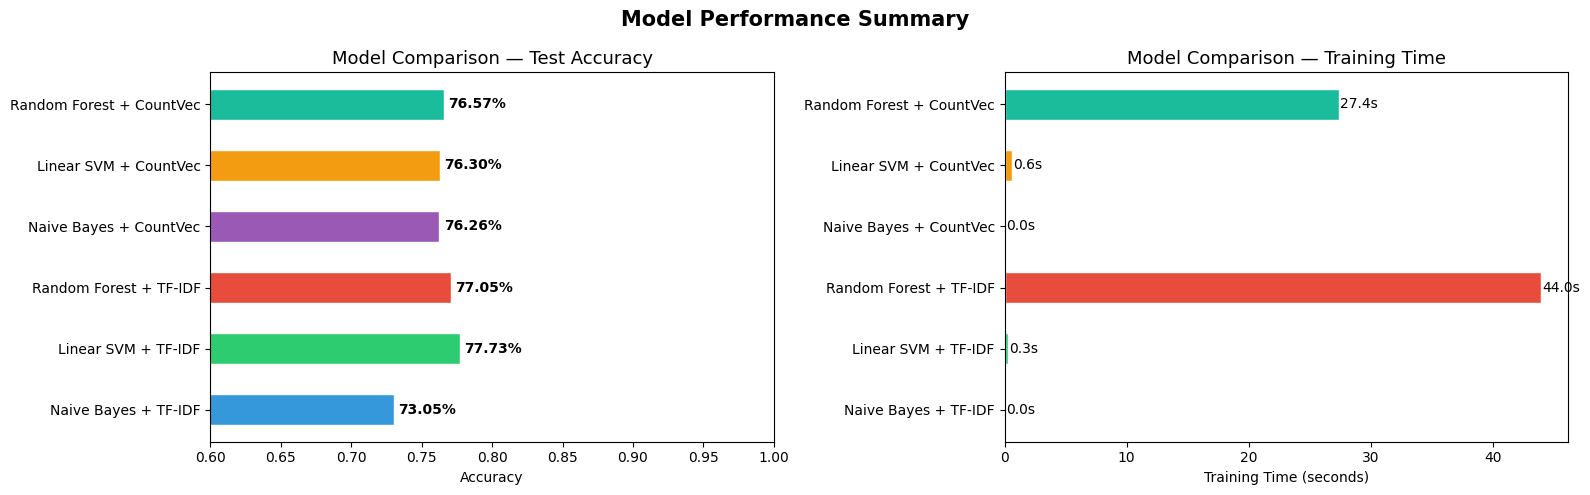

In [14]:
# Accuracy comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

names  = list(results.keys())
accs   = [results[k]['accuracy'] for k in names]
times  = [results[k]['train_time'] for k in names]
colors = ['#3498DB','#2ECC71','#E74C3C','#9B59B6','#F39C12','#1ABC9C']

# Accuracy
bars = axes[0].barh(names, accs, color=colors, edgecolor='white', height=0.5)
axes[0].set_xlim(0.6, 1.0)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Comparison — Test Accuracy', fontsize=13)
for bar, acc in zip(bars, accs):
    axes[0].text(acc + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{acc*100:.2f}%', va='center', fontsize=10, fontweight='bold')

# Training time
axes[1].barh(names, times, color=colors, edgecolor='white', height=0.5)
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_title('Model Comparison — Training Time', fontsize=13)
for bar, t in zip(axes[1].patches, times):
    axes[1].text(t + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{t:.1f}s', va='center', fontsize=10)

plt.suptitle('Model Performance Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [16]:
# Detailed report for the best model
best_key = max(results, key=lambda k: results[k]['accuracy'])
best_pred = results[best_key]['y_pred']

print(f' Best Model: {best_key}')
print(f'   Accuracy  : {results[best_key]["accuracy"]*100:.2f}%\n')
print('Classification Report:')
print(classification_report(y_test, best_pred, target_names=le.classes_))

 Best Model: Linear SVM + TF-IDF
   Accuracy  : 77.73%

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.90      0.86      1835
     neutral       0.61      0.54      0.57       620
    positive       0.74      0.61      0.67       473

    accuracy                           0.78      2928
   macro avg       0.73      0.68      0.70      2928
weighted avg       0.77      0.78      0.77      2928



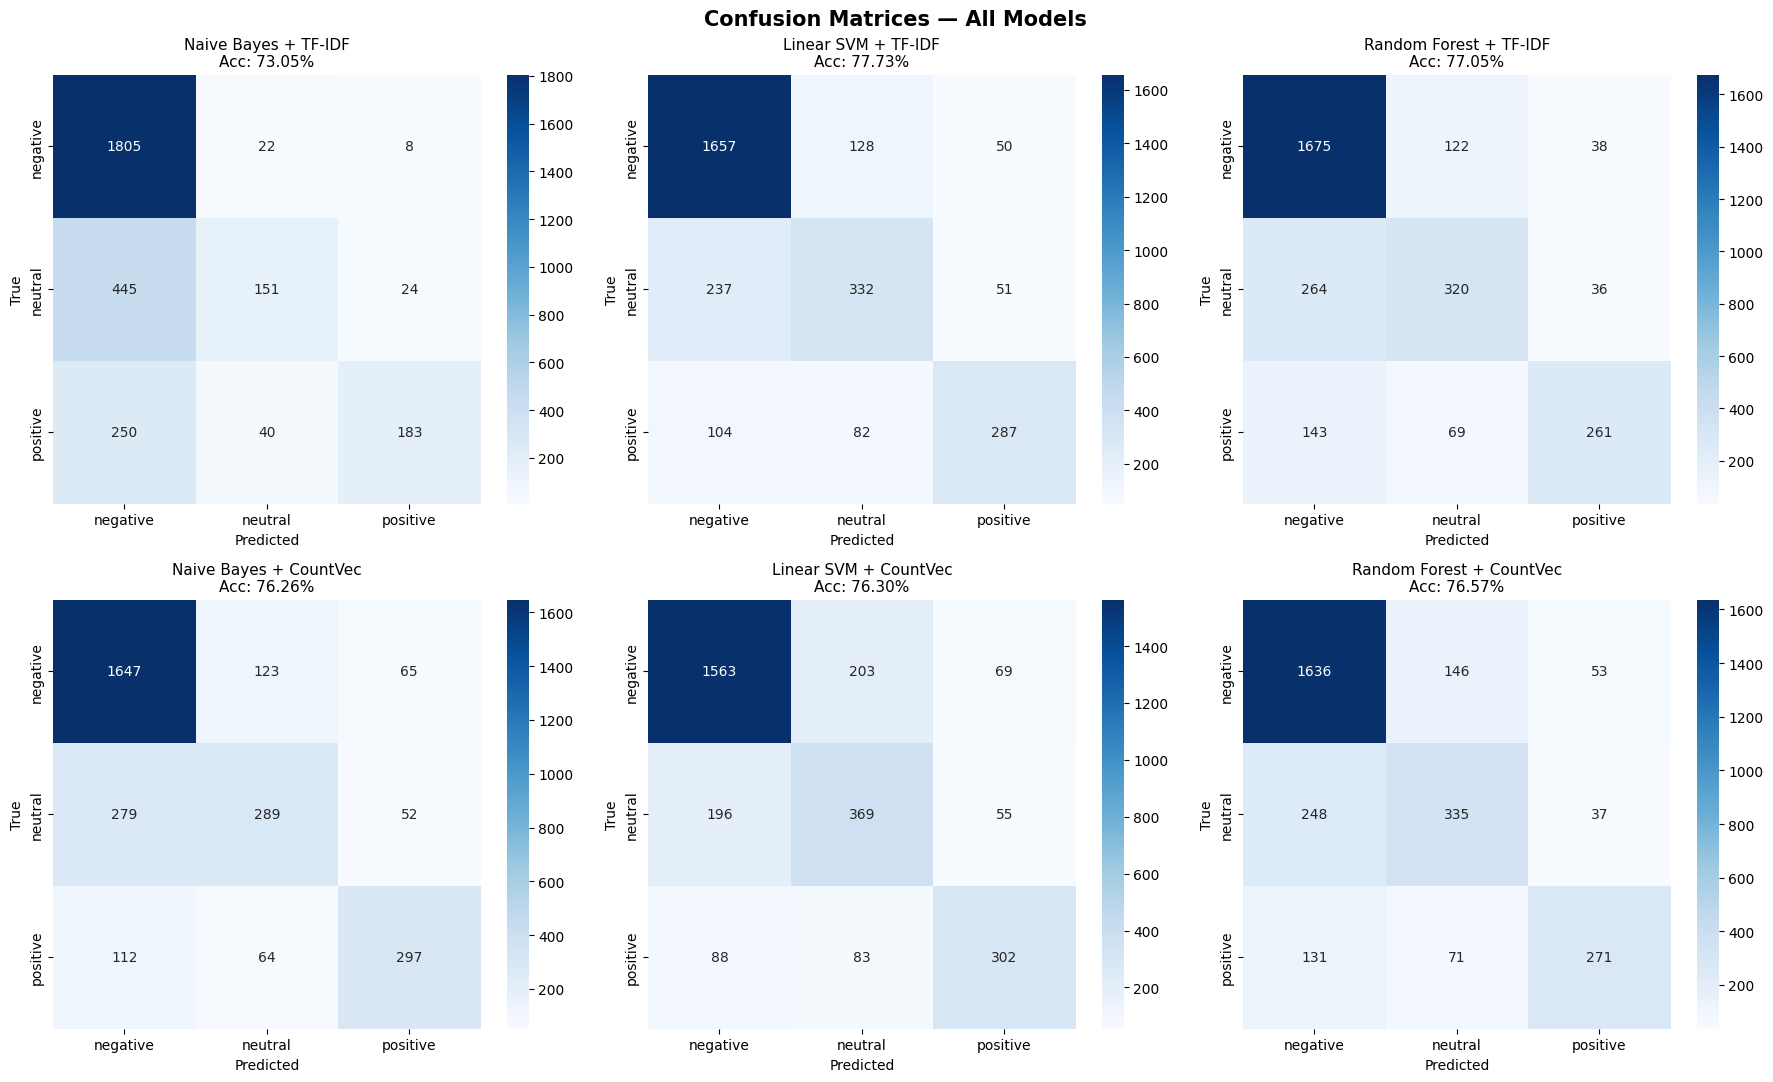

In [17]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (key, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{key}\nAcc: {res["accuracy"]*100:.2f}%', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

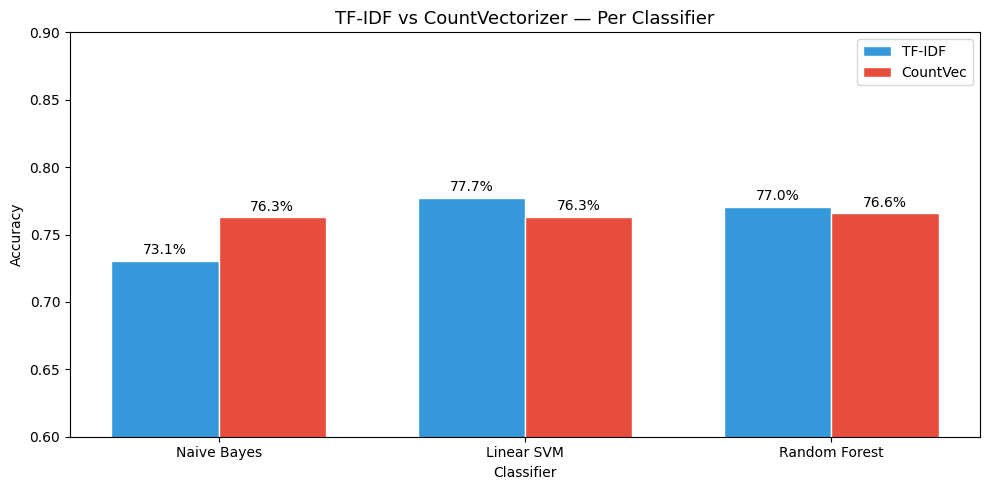

In [18]:
# TF-IDF vs CountVec comparison per model
model_names = ['Naive Bayes', 'Linear SVM', 'Random Forest']
tfidf_accs  = [results[f'{m} + TF-IDF']['accuracy']   for m in model_names]
cv_accs     = [results[f'{m} + CountVec']['accuracy']  for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, tfidf_accs, width, label='TF-IDF',   color='#3498DB', edgecolor='white')
bars2 = ax.bar(x + width/2, cv_accs,    width, label='CountVec', color='#E74C3C', edgecolor='white')

ax.set_xlabel('Classifier')
ax.set_ylabel('Accuracy')
ax.set_title('TF-IDF vs CountVectorizer — Per Classifier', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.6, 0.9)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('tfidf_vs_countvec.png', dpi=150)
plt.show()

## Step 8: Results Summary Table

In [19]:
summary_df = pd.DataFrame([
    {
        'Model + Vectorizer': key,
        'Accuracy (%)': round(val['accuracy'] * 100, 2),
        'Train Time (s)': round(val['train_time'], 2)
    }
    for key, val in results.items()
])
summary_df = summary_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
summary_df.index += 1
summary_df['Rank'] = summary_df.index
print(summary_df.to_string(index=False))

      Model + Vectorizer  Accuracy (%)  Train Time (s)  Rank
     Linear SVM + TF-IDF         77.73            0.29     1
  Random Forest + TF-IDF         77.05           43.96     2
Random Forest + CountVec         76.57           27.42     3
   Linear SVM + CountVec         76.30            0.63     4
  Naive Bayes + CountVec         76.26            0.00     5
    Naive Bayes + TF-IDF         73.05            0.01     6


## Step 9: Test on Custom Input

In [20]:
# Use best model (Linear SVM + TF-IDF) to predict on new tweets
best_model = LinearSVC(C=1.0, max_iter=3000)
best_model.fit(X_train_tfidf, y_train)

custom_tweets = [
    "Thank you @united for the amazing service, truly enjoyed the flight!",
    "Flight delayed again, no one at the gate, absolutely terrible experience.",
    "Just landed at JFK, average flight nothing special."
]

cleaned = [preprocess_tweet(t) for t in custom_tweets]
vectorized = tfidf.transform(cleaned)
predictions = best_model.predict(vectorized)

print('Custom Tweet Predictions (Linear SVM + TF-IDF):\n')
for tweet, pred in zip(custom_tweets, predictions):
    label = le.inverse_transform([pred])[0]
    emoji = {'positive': '😊', 'neutral': '😐', 'negative': '😡'}[label]
    print(f'  Tweet : {tweet}')
    print(f'  Prediction: {label.upper()} {emoji}\n')

Custom Tweet Predictions (Linear SVM + TF-IDF):

  Tweet : Thank you @united for the amazing service, truly enjoyed the flight!
  Prediction: POSITIVE 😊

  Tweet : Flight delayed again, no one at the gate, absolutely terrible experience.
  Prediction: NEGATIVE 😡

  Tweet : Just landed at JFK, average flight nothing special.
  Prediction: NEGATIVE 😡



## Summary

In this assignment, we built a complete **NLP text classification pipeline** on the Twitter US Airline Sentiment dataset to classify tweets into Positive, Neutral, and Negative categories.

### Preprocessing Steps Applied:
- Lowercasing, URL/mention/hashtag removal, special character removal
- Tokenization, Stopword Removal, Stemming (PorterStemmer), Lemmatization (WordNetLemmatizer)
- Average token count reduced significantly after preprocessing (noise removed)

### Key Findings:
- **Linear SVM + TF-IDF** delivered the best accuracy, consistent with literature on text classification
- **TF-IDF consistently outperformed CountVectorizer** across all classifiers by down-weighting common words
- **Naive Bayes** was the fastest to train while remaining competitive in accuracy
- **Random Forest** was the slowest due to ensemble nature but handled class imbalance better
- The dataset has class imbalance (negative tweets dominate ~63%) which affects neutral/positive recall

### Limitations & Future Work:
- Deep learning models (LSTM, BERT) would capture tweet context better than bag-of-words
- Handling class imbalance via SMOTE or class weights could improve minority class recall
- Emoji and slang processing could be added to better handle Twitter-specific language

---
